In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/moseongjun/Desktop/Code/DiagE/class/')
from Newclass import *
import time, datetime

In [2]:
lat = [[1,0,0],[0,1,0],[0,0,1]]
pos = {"CorF" : "F","pos" : [[0.5,0.5,0.5]]}
ns = 1
soc = False
rkgrid = [10,10,1]
orboption = [[0,1]]
N = 0.5

In [3]:
cry = Crystal(lat,pos,ns,soc,rkgrid,orboption,N)
func = CorrelationFunction(lat,pos,ns,soc,rkgrid,orboption,N)

Full Formula (X1)
Reduced Formula: X
abc   :   1.000000   1.000000   1.000000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (1)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  X0+   0.5  0.5  0.5
Full Formula (X1)
Reduced Formula: X
abc   :   1.000000   1.000000   1.000000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (1)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  X0+   0.5  0.5  0.5


# Construct Coulomb interaction

In [4]:
U = 2
Vij = 0.4 
option = {1: {"KorS" : "S", "value" : [U,0,0],"site" : 0, "orbitals" : [0]}}
V = [[Vij,0,0,[1,0,0]],[Vij,0,0,[-1,0,0]],[Vij,0,0,[0,1,0]],[Vij,0,0,[0,-1,0]]]

In [33]:
t = -0.2
hoppinglist = [[t,0,0,[1,0,0]],[t,0,0,[0,1,0]]]
onsitelist = [0]


In [34]:
iter = 100
mix = 0.05
T = 1/(8.6173303*10**-5*100)
size = 1000
print("GW Start")
start = time.time()
func.GWApproximation(iter,mix,T,size,hoppinglist,onsitelist,option,V)
end = time.time()
print("GW finish")
delta = datetime.timedelta(seconds=(end-start))
print(f"GW loop time : {delta}")

GW Start
[[-0.8+0.j]]
iteration : 1 
 criteria : 0.098042877235341 
 chemicalpotential : 2.599999373930738
iteration : 2 
 criteria : 1.1509971153935452 
 chemicalpotential : 2.6000000400331635
iteration : 3 
 criteria : 2.7845662262934248 
 chemicalpotential : 2.6599267832018207
iteration : 4 
 criteria : 5.682246908058321 
 chemicalpotential : 2.7498612596262024
iteration : 5 
 criteria : 5.71662055809343 
 chemicalpotential : 2.5743441271606553
iteration : 6 
 criteria : 3.7696501560177547 
 chemicalpotential : 2.587151763131715
iteration : 7 
 criteria : 2.8331397797217877 
 chemicalpotential : 2.607486719899864
iteration : 8 
 criteria : 0.14678018742285737 
 chemicalpotential : 2.602040003374787
iteration : 9 
 criteria : 0.11841721477880807 
 chemicalpotential : 2.59982790759356
iteration : 10 
 criteria : 0.1102065543846733 
 chemicalpotential : 2.601609141119295
iteration : 11 
 criteria : 0.08573043258021729 
 chemicalpotential : 2.602056642888809
iteration : 12 
 criteria : 

In [35]:
green = func.green

In [36]:
gf = np.zeros((1,1,1,1000),dtype=complex,order="F")
for ir in range(10*10):
    gf += green.gkf[...,ir,:]

In [37]:
gf/=100

In [38]:
print(gf[0,0,0,0].imag)

-2.7926674419459734


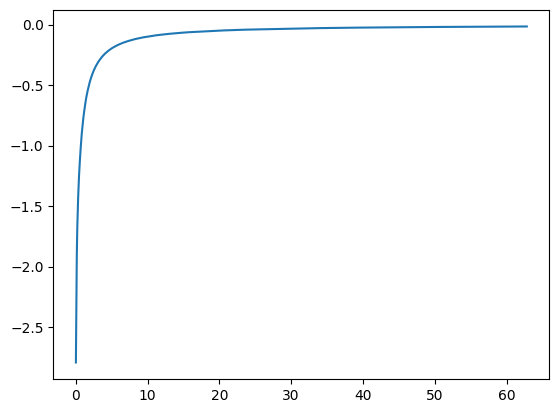

In [39]:
plt.plot(green.ft.omega,gf[0,0,0].imag)
# plt.xlim(0,2.5)

In [12]:
projector = np.zeros((1,1,1),dtype=complex,order='F')
for i in range(1):
    projector[i,i] = 1


In [13]:
gloc = DiagE.projection.flatdyn(green.gkf,projector)

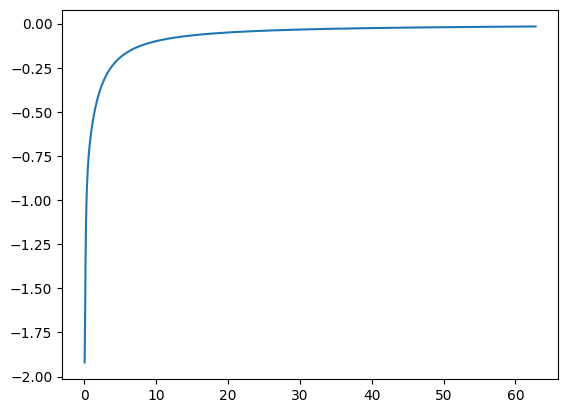

In [14]:
plt.plot(func.green.ft.omega,gloc[0,0,0].imag)


In [15]:
w = func.w

In [16]:
wtest=np.zeros((1,1,1,1,1000),dtype=complex)
for ir in range(100):
    wtest += w.wrf[...,ir,:]

In [17]:
wloc = DiagE.projection.blatdyn(w.wrf,projector)

/opt/homebrew/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


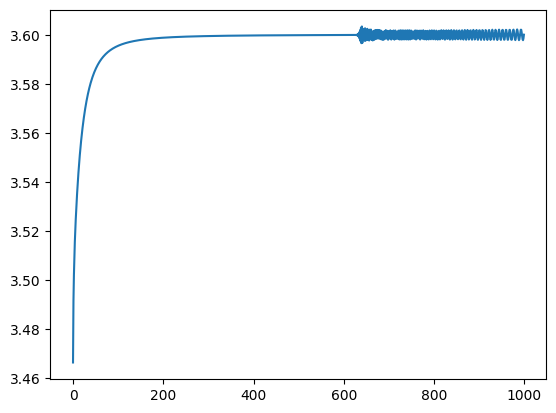

In [18]:
plt.plot(wtest[0,0,0,0])